# Predicción de abandono de clientes (Churn)

Una empresa de telecomunicaciones quiere mejorar la retención de clientes y necesita predecir qué usuarios tienen más probabilidad de abandonar el servicio.

## Variables del dataset

- **Edad**: edad del cliente.
- **Ingresos**: ingresos mensuales del cliente.
- **Antigüedad**: años como cliente.
- **GastoMedio**: gasto mensual.
- **Churn**: variable objetivo (**1 = abandona**, **0 = no abandona**).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
## Cargamos los datos

data = pd.read_excel(r"customer churn.xlsx")

data.head()

,idcliente,Edad,Ingresos,Antiguedad,GastoMensual,Churn
0,1,33,2845.202995,11,36.168961,0
1,2,66,6063.797330,7,27.149305,0
2,3,56,2593.151291,13,46.387221,0
3,4,55,7075.617838,18,12.359331,0
4,5,65,6690.148651,21,35.445138,0


In [3]:
#Definicion del modelo

x = data[["Edad", "Ingresos", "Antiguedad", "GastoMensual"]]
y = data["Churn"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [5]:
# Entrenamiento del modelo (Aquí se puede cambiar el modelo a RandomForestClassifier si se desea)

tree = DecisionTreeClassifier(max_depth=6, random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

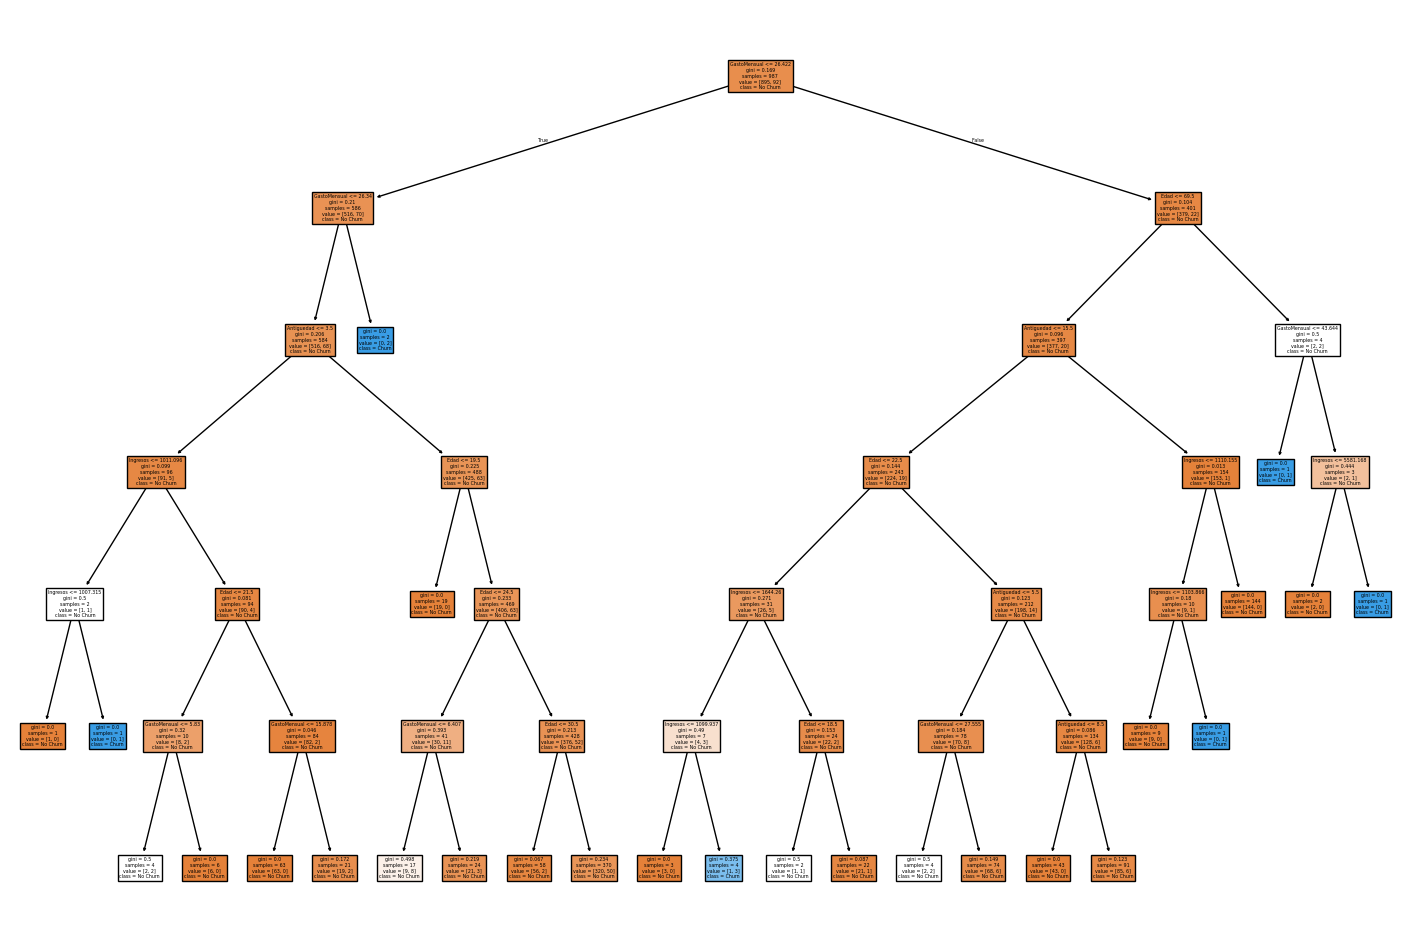

In [6]:
#Visualizar el árbol de decisión


plt.figure(figsize=(18, 12))

plot_tree(
    tree,
    feature_names=x.columns,
    class_names=["No Churn", "Churn"],
    filled=True
)


plt.show()

In [7]:
# Evaluar el modelo

print("Arbol de decisión - Métricas de evaluación")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree, target_names=["No Churn", "Churn"]))

Arbol de decisión - Métricas de evaluación
Accuracy: 0.902834008097166
Matriz de confusión:
[[222   2]
 [ 22   1]]
              precision    recall  f1-score   support

    No Churn       0.91      0.99      0.95       224
       Churn       0.33      0.04      0.08        23

    accuracy                           0.90       247
   macro avg       0.62      0.52      0.51       247
weighted avg       0.86      0.90      0.87       247



In [8]:
# Importancia o contribución de cada variable individual al fenomeno churning

importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": tree.feature_importances_
}).sort_values(by="importance", ascending=False)
print(importances)

        feature  importance
3  GastoMensual    0.384344
1      Ingresos    0.293182
0          Edad    0.234669
2    Antiguedad    0.087805


In [9]:
from sklearn.tree import export_text

rules = export_text(tree, feature_names=list(x.columns))
print(rules)

|--- GastoMensual <= 26.42
|   |--- GastoMensual <= 26.34
|   |   |--- Antiguedad <= 3.50
|   |   |   |--- Ingresos <= 1011.10
|   |   |   |   |--- Ingresos <= 1007.32
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Ingresos >  1007.32
|   |   |   |   |   |--- class: 1
|   |   |   |--- Ingresos >  1011.10
|   |   |   |   |--- Edad <= 21.50
|   |   |   |   |   |--- GastoMensual <= 5.83
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- GastoMensual >  5.83
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- Edad >  21.50
|   |   |   |   |   |--- GastoMensual <= 15.88
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- GastoMensual >  15.88
|   |   |   |   |   |   |--- class: 0
|   |   |--- Antiguedad >  3.50
|   |   |   |--- Edad <= 19.50
|   |   |   |   |--- class: 0
|   |   |   |--- Edad >  19.50
|   |   |   |   |--- Edad <= 24.50
|   |   |   |   |   |--- GastoMensual <= 6.41
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- GastoMensu

## Random Forest

In [10]:
# Construir el modelo random forest 

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
y_pred_rf = rf.predict(X_test)

In [12]:
print("RANDOM FOREST - Métricas de evaluación")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=["No Churn", "Churn"]))

RANDOM FOREST - Métricas de evaluación
Accuracy: 0.9068825910931174
Matriz de confusión:
[[224   0]
 [ 23   0]]
              precision    recall  f1-score   support

    No Churn       0.91      1.00      0.95       224
       Churn       0.00      0.00      0.00        23

    accuracy                           0.91       247
   macro avg       0.45      0.50      0.48       247
weighted avg       0.82      0.91      0.86       247



c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

# XGBOOST

In [13]:
from xgboost import XGBClassifier, plot_importance, plot_tree, to_graphviz
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [ ]:
# ============================================================
# 1. DEFINICIÓN DEL MODELO
# ============================================================
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

In [15]:
# ============================================================
# 2. ENTRENAMIENTO
# ============================================================
xgb_model.fit(X_train, y_train)

# ============================================================
# 3. PREDICCIÓN Y MÉTRICAS
# ============================================================
y_pred = xgb_model.predict(X_test)

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8906882591093117

Matriz de confusión:
[[220   4]
 [ 23   0]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       224
           1       0.00      0.00      0.00        23

    accuracy                           0.89       247
   macro avg       0.45      0.49      0.47       247
weighted avg       0.82      0.89      0.85       247



<Figure size 1000x600 with 0 Axes>

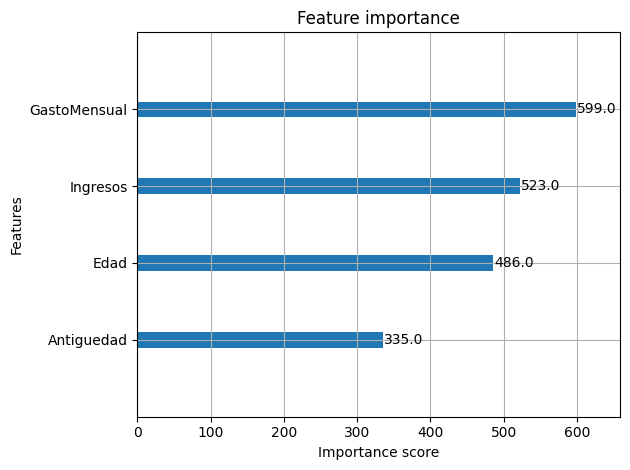

In [17]:
# ============================================================
# 4. IMPORTANCIA DE CARACTERÍSTICAS
# ============================================================
plt.figure(figsize=(10, 6))
plot_importance(xgb_model)
plt.tight_layout()  # ← evita que las etiquetas se corten
plt.show()


<Figure size 5000x3000 with 0 Axes>

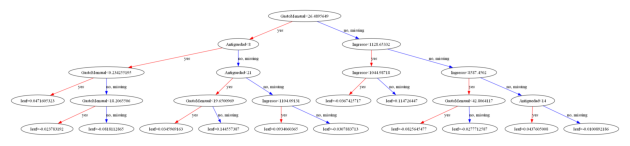

In [20]:
# ============================================================
# 5. VISUALIZACIÓN DE UN ÁRBOL (árbol nº 0)
# ============================================================
plt.figure(figsize=(50, 30))
plot_tree(xgb_model, num_trees=0)
plt.tight_layout()
plt.show()

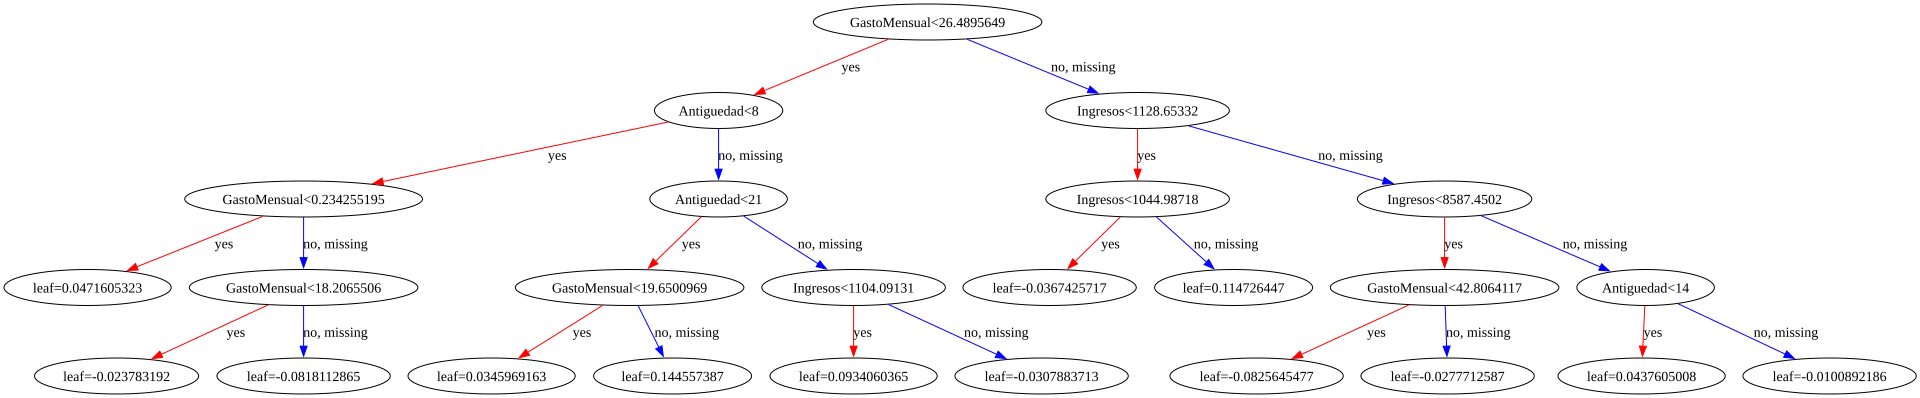

In [21]:
from xgboost import to_graphviz

graph = to_graphviz(xgb_model, num_trees=0)
graph  # ← esta línea es obligatoria en Jupyter para que se renderice